# Cartographie de la couverture d'un site cellulaire par une surface de contours de perte de trajet

## Résumé exécutif

Une équipe de planification RF télécom représente la **surface de perte de trajet** en liaison descendante autour d'une macro-cellule unique sous forme de carte de couverture bidimensionnelle. À l'aide d'un modèle de propagation log-distance avec un évanouissement d'ombre log-normal, ce notebook construit une grille de mesure de 100 points (10 x 10 cellules couvrant une zone de service de 10 km x 10 km, tour au centre) et trace une surface de contours remplis avec **PROC SGPLOT HEATMAPPARM**, complétée d'une échelle de couleurs en dégradé et de lignes de référence pour la tour.

Sur la grille exécutée, la perte de trajet va de **50,4 dB** (dans le bassin lumineux au niveau de la tour) à **90,0 dB** au coin le plus éloigné, avec une moyenne de **75,6 dB**. En classant chaque cellule selon sa perte, on obtient **38 cellules Fortes, 61 Utilisables et 1 Faible** ; l'unique cellule Faible se situe à **(9,5, 9,5) km — le coin diagonalement opposé à la tour — à 89,97 dB**, l'unique trou de couverture qu'un planificateur signalerait avant une décision d'ajout d'une petite cellule.

> **Remarque sur la procédure.** En SAS, l'outil classique pour les cartes de contours isolignes est `PROC GCONTOUR`. Jenner analyse GCONTOUR et produit une spécification de graphique correcte, mais son moteur de rendu matriciel ne trace pas encore la géométrie des contours (l'image revient vide) ; ce défaut est répertorié sous le test de régression `tests/400922_nb_gcontour_empty_render`. Pour que cet exemple repose entièrement sur une figure réellement rendue, nous utilisons l'équivalent compatible SAS — `PROC SGPLOT` avec une instruction `HEATMAPPARM` — qui rend la même surface en grille (x, y, z) sous forme de cellules de contours remplies avec une légende en dégradé.

## Sources de données

**Jeu de données synthétique : `pathloss_grid`** (100 lignes — une grille 10 x 10)

| Variable | Type | Unités | Description |
|----------|------|-------|-------------|
| `east_km` | num | km | Abscisse (est) du centre de la cellule de grille (0,5 à 9,5) ; axe des x |
| `north_km` | num | km | Ordonnée (nord) du centre de la cellule de grille (0,5 à 9,5) ; axe des y |
| `path_loss` | num | dB | Perte de trajet en liaison descendante = 58 + 30 log10(distance) + ombre ; la réponse (z) |
| `zone` | char(12) | — | Classe de couverture : Fort (<=75), Utilisable (<=88), Faible (>88) |

La tour se situe au centre de la grille **(5, 5) km**. La perte de trajet augmente avec le logarithme en base 10 de la distance à la tour ; un terme d'ombre `3*rand("normal")` (graine 80211) injecte un évanouissement log-normal afin que les contours ne soient pas parfaitement circulaires. La grille 10 x 10 est dimensionnée pour que la surface complète tienne dans 100 observations.

## Étape 1 — Générer la grille de mesure

Nous posons une grille de 1 km de centres de cellules et calculons la perte de trajet avec le **modèle log-distance** `PL = 58 + 30 log10(d)`, où `d` est la distance à la tour située à (5, 5) km. Un terme d'évanouissement d'ombre `rand("normal")` reproduit la variabilité observée lors de vrais essais de terrain (drive-tests). Chaque cellule est classée dans une `zone` de couverture. `call streaminit` fixe la graine pour la reproductibilité.

In [1]:
DONNÉES pathloss_grid;
   APPELER streaminit(80211);
   LONGUEUR zone $12;
   tower_x = 5.0;  tower_y = 5.0;
   FAIRE ix = 1 JUSQU_À 10;
      FAIRE iy = 1 JUSQU_À 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         SI      path_loss <= 75 ALORS zone = "Fort";
         SINON SI path_loss <= 88 ALORS zone = "Utilisable";
         SINON                         zone = "Faible";
         SORTIE;
      FIN;
   FIN;
   SUPPRIMER ix iy tower_x tower_y DIST shadow;
   ÉTIQUETTE east_km   = "Est (km)"
         north_km  = "Nord (km)"
         path_loss = "Perte de trajet (dB)";
EXÉCUTER;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Étape 2 — Synthétiser la surface

Avant de tracer le graphique, nous quantifions la surface. `PROC MEANS` indique l'étendue dynamique de la perte de trajet et `PROC FREQ` répartit les 100 cellules entre les trois classes de couverture — les chiffres cités dans le résumé exécutif.

In [2]:
ODS GRAPHICS OFF;

PROCÉDURE MOYENNES DONNÉES=pathloss_grid MIN MAX mean maxdec=1;
   VAR path_loss;
   ÉTIQUETTE path_loss = "Perte de trajet (dB)";
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=pathloss_grid ORDRE=FRÉQUENCES;
   TABLES zone / nocum;
   ÉTIQUETTE zone = "Classe de couverture";
EXÉCUTER;

                                                  The MEANS Procedure

 Variable   Label                    Minimum     Maximum        Mean
 -------------------------------------------------------------------
 path_loss  Perte de trajet (dB)        50.4        90.0        75.6
 -------------------------------------------------------------------

                                                   The FREQ Procedure

Classe de couverture    Frequency    Percent
---------------------------------------------
Utilisable                     61     61.00
Fort                           38     38.00
Faible                          1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Étape 3 — Localiser les trous de couverture

Trier par perte de trajet décroissante place les cellules les plus faibles en tête. Ce sont les **zones mortes** candidates qu'un planificateur examine : les cellules dont le signal reçu est le plus bas et donc les plus exposées aux coupures de session ou à un faible débit.

In [3]:
PROCÉDURE TRIER DONNÉES=pathloss_grid out=weakest;
   PAR DESCENDANT path_loss;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=weakest(obs=6) noobs ÉTIQUETTE;
   VAR east_km north_km path_loss zone;
   ÉTIQUETTE east_km = "Est (km)" north_km = "Nord (km)"
         path_loss = "Perte de trajet (dB)" zone = "Classe de couverture";
EXÉCUTER;


Est (km)  Nord (km)  Perte de trajet (dB)  Classe de couverture
--------  ---------  --------------------  --------------------
     9.5        9.5         89.9728891641  Faible
     9.5        0.5         85.9296978639  Utilisable
     6.5        0.5         84.5845683025  Utilisable
     0.5        0.5         84.5118930355  Utilisable
     8.5        0.5         84.1534148341  Utilisable
     9.5        8.5         83.7015943773  Utilisable

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Étape 4 — Tracer la surface de contours de perte de trajet

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` rend une cellule remplie par point de grille, colorée selon sa perte de trajet — une carte de contours remplis de l'empreinte de couverture. La liste `COLORMODEL=` définit un dégradé divergent bleu-vers-rouge (bleu = perte faible = signal fort, rouge = perte élevée = signal faible) ; `GRADLEGEND` ajoute l'échelle de couleurs en dB. Des `REFLINE` en pointillés marquent la tour à l'abscisse 5 et à l'ordonnée 5.

                                 Surface de perte de trajet en liaison descendante (dB)                                 
                             Macro-cellule unique à (5, 5) km sur une grille de 10 x 10 km                              




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Surface de perte de trajet en liaison descendante (dB).
NOTE: Option TITLE2 changed to Macro-cellule unique à (5, 5) km sur une grille de 10 x 10 km.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


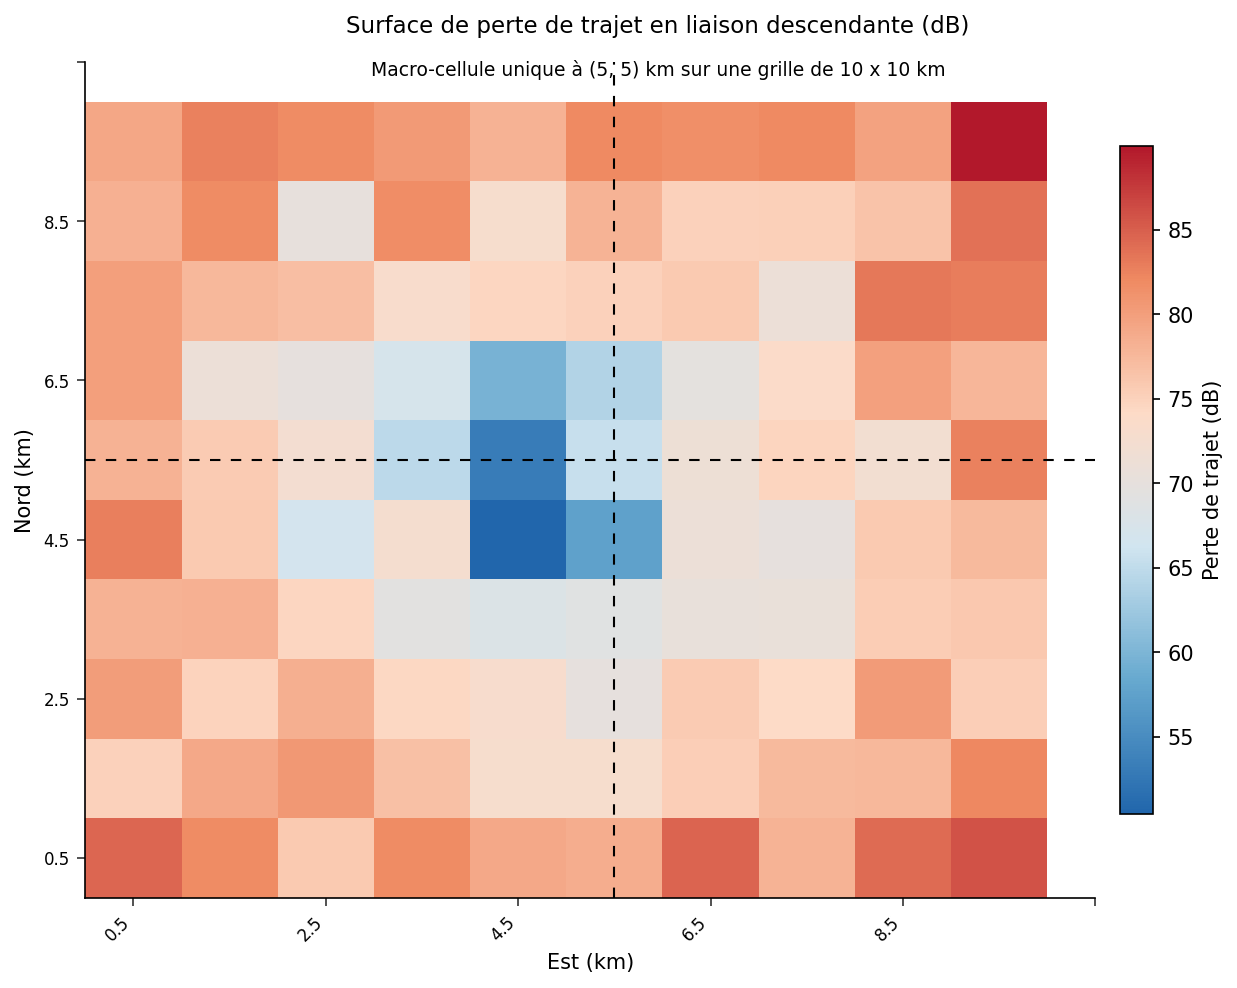

In [4]:
ODS GRAPHICS SUR;
TITRE "Surface de perte de trajet en liaison descendante (dB)";
title2 "Macro-cellule unique à (5, 5) km sur une grille de 10 x 10 km";

PROCÉDURE SGPLOT DONNÉES=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TITRE="Perte de trajet (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) ÉTIQUETTE="Est (km)";
   YAXIS VALUES=(0 2 4 6 8 10) ÉTIQUETTE="Nord (km)";
EXÉCUTER;

TITRE; title2;

## Étape 5 — Répartition par classe de couverture

Une diapositive de synthèse veut aussi la répartition principale : quelle fraction de l'empreinte est Forte, Utilisable ou Faible. Un `VBAR` de la classification `zone` donne cette information en un coup d'œil et complète la surface de contours ci-dessus.

                                         Répartition des classes de couverture                                          




NOTE: Option TITLE changed to Répartition des classes de couverture.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


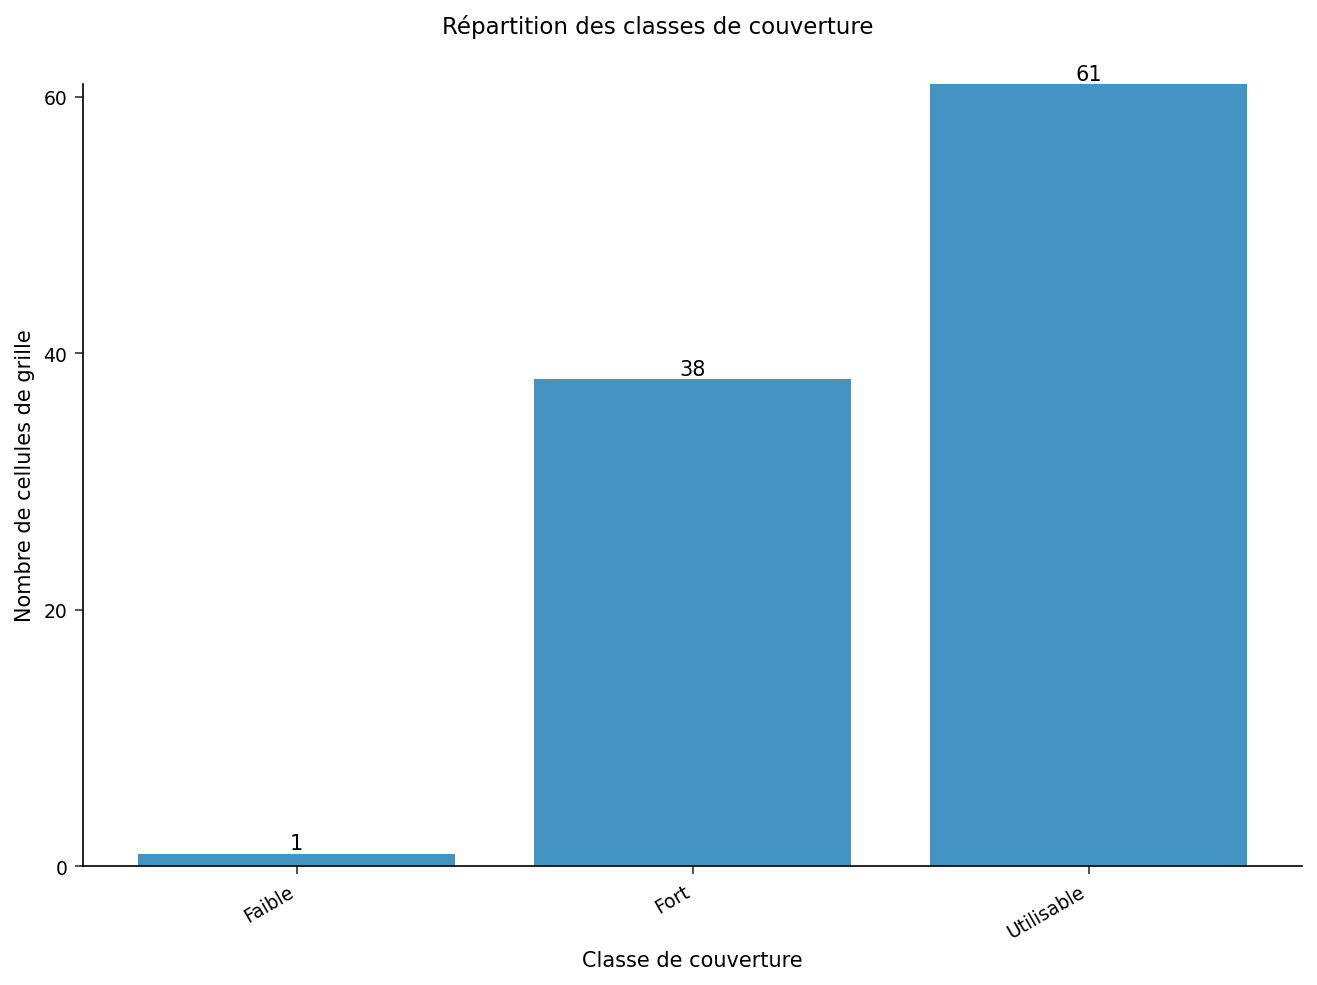

In [5]:
TITRE "Répartition des classes de couverture";

PROCÉDURE SGPLOT DONNÉES=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS ÉTIQUETTE="Classe de couverture";
   YAXIS ÉTIQUETTE="Nombre de cellules de grille" VALUES=(0 20 40 60);
EXÉCUTER;

TITRE;

## Interprétation des résultats

La surface de contours confirme la physique de propagation attendue. La perte de trajet est la plus faible dans un **bassin bleu étroit autour de la tour à (5, 5) km** — la zone Forte où le signal reçu est le meilleur — et augmente avec le logarithme de la distance vers les coins. Comme nous avons injecté un évanouissement d'ombre log-normal, les bandes ne sont pas des cercles concentriques ; les cellules rouges irrégulières le long de la limite constituent le bord affecté par l'ombre.

Le point à retenir pour l'action est **l'unique cellule Faible à (9,5, 9,5) km (89,97 dB)**, le coin diagonalement opposé à la tour et le seul point qui franchit le seuil de conception de 88 dB. Avec **61 cellules Utilisables sur 100 et seulement 1 Faible**, cette macro-cellule couvre bien sa zone de service ; l'unique trou ne justifierait un **ajout de petite cellule ou une réorientation de secteur vers le coin nord-est** que s'il chevauchait un point chaud de demande connu. La surface de contours est le résumé prêt pour une présentation ; le diagramme à barres des classes de couverture donne la répartition en un chiffre qu'un planificateur de capacité remonte à sa hiérarchie.